# M-CaStLe-PC: Performance vs. Number of Time Steps

Evaluates how M-CaStLe-PC performs as a function of observed time steps, with **30 replicates per T** to characterize variance.

**Configuration:**
- Grid: 12 × 12
- Variables: 2
- Time steps swept: T ∈ {2, 3, 4, 8, 16}
- Replicates per T: 30 (each with a different random seed)
- Coefficients are fixed across all replicates and T values (same true graph).

## Setup

In [1]:
import sys
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

from tigramite.independence_tests.parcorr import ParCorr

sys.path.append("../src")
import spatiotemporal_SCM_data_generator as dg
import mcastle_utils as mcastle
import causal_graph_metrics as gm

## Configuration

In [2]:
GRID_SIZE  = 12
N_VARS     = 2
T_VALUES   = [2, 3, 4, 8, 16]
N_REPS     = 30
COEF_SEED  = 0        # seed used to generate the fixed coefficients
USE_SEEDS  = False    # True = seed each replicate (rep index as seed); False = fully random

# Data generation (noise / dynamics)
GEN_PARAMS = dict(
    grid_size                       = GRID_SIZE,
    num_variables                   = N_VARS,
    error_sigma                     = 0.1,
    error_mean                      = 0.0,
    initialize_randomly             = True,
)

# M-CaStLe-PC
PC_ALPHA    = 0.1
P_THRESHOLD = 0.1
PARCORR     = ParCorr(significance="analytic")

## Generate Fixed Coefficients

Coefficients are generated once and shared across all T values and all replicates, so every run is evaluated against the same true causal graph.

In [3]:
np.random.seed(COEF_SEED)
spatial_coefs, _ = dg.generate_dataset(
    T=max(T_VALUES),
    num_variables=N_VARS,
    grid_size=GRID_SIZE,
    dependence_density=0.3,
    coefficient_min_value_threshold=0.1,
    min_val_scaler=1.0,
    error_sigma=0.1,
    detect_instability=True,
    # instability_threshold=500,
    return_coefs=True,
)

true_stencil, true_stencil_vals = mcastle.get_stencil_graph_from_coefficients(spatial_coefs)
true_full_graph = mcastle.map_stencil_graph_to_full_graph(true_stencil, grid_size=GRID_SIZE)

n_true_edges = int(np.sum(true_full_graph == "-->"))
print(f"True stencil shape : {true_stencil.shape}")
print(f"True full graph shape: {true_full_graph.shape}")
print(f"True edges (-->): {n_true_edges}")

True stencil shape : (18, 18, 2)
True full graph shape: (288, 288, 2)
True edges (-->): 1440


## Replicated Sweep over T

In [4]:
results_by_T = {T: [] for T in T_VALUES}

for T in T_VALUES:
    print(f"\nT = {T}")
    for rep in range(N_REPS):
        if USE_SEEDS:
            np.random.seed(rep)

        # Generate data with fixed coefficients, independent noise per replicate
        data = dg.generate_dataset(
            T=T,
            spatial_coefs=spatial_coefs,
            **GEN_PARAMS,
        )

        # Run M-CaStLe-PC
        t0 = time.time()
        pc_results = mcastle.mv_CaStLe_PC(
            data=data,
            cond_ind_test=PARCORR,
            pc_alpha=PC_ALPHA,
            graph_p_threshold=P_THRESHOLD,
            min_tau=1,
            cd_function="run_pcalg",
            rows_inverted=True,
            verbose=0,
        )
        elapsed = time.time() - t0

        discovered_stencil = pc_results["graph"]
        discovered_full    = mcastle.map_stencil_graph_to_full_graph(
            discovered_stencil, grid_size=GRID_SIZE
        )

        TP, FP, FN, TN = gm.get_confusion_matrix(true_full_graph, discovered_full)
        F1, P, R, *_   = gm.F1_score(TP=TP, FP=FP, FN=FN, TN=TN)
        MCC = gm.matthews_correlation_coefficient(TP=TP, FP=FP, FN=FN, TN=TN)
        FDR = gm.false_discovery_rate(FP, TP)

        results_by_T[T].append(dict(
            rep=rep, T=T,
            F1=F1, Precision=P, Recall=R, MCC=MCC, FDR=FDR,
            TP=TP, FP=FP, FN=FN, TN=TN,
            time_s=elapsed,
            stencil=discovered_stencil,
        ))

        if (rep + 1) % 10 == 0:
            print(f"  rep {rep+1:2d}/{N_REPS}  F1={F1:.3f}  MCC={MCC:.3f}")

print("\nDone.")


T = 2
  rep 10/30  F1=0.444  MCC=0.443
  rep 20/30  F1=0.588  MCC=0.595
  rep 30/30  F1=0.737  MCC=0.736

T = 3
  rep 10/30  F1=0.737  MCC=0.736
  rep 20/30  F1=0.750  MCC=0.773
  rep 30/30  F1=0.842  MCC=0.842

T = 4
  rep 10/30  F1=0.778  MCC=0.781
  rep 20/30  F1=0.824  MCC=0.836
  rep 30/30  F1=0.947  MCC=0.948

T = 8
  rep 10/30  F1=0.889  MCC=0.894
  rep 20/30  F1=0.947  MCC=0.948
  rep 30/30  F1=0.900  MCC=0.899

T = 16
  rep 10/30  F1=0.909  MCC=0.912
  rep 20/30  F1=0.824  MCC=0.836
  rep 30/30  F1=0.947  MCC=0.948

Done.


## Aggregate Statistics

In [5]:
def agg(T, key):
    vals = [r[key] for r in results_by_T[T]]
    return np.mean(vals), np.std(vals)

metrics_keys = ["F1", "Precision", "Recall", "MCC", "FDR", "TP", "FP", "FN", "time_s"]
agg_results  = {T: {k: agg(T, k) for k in metrics_keys} for T in T_VALUES}

# Print table
header = f"{'T':>4}  {'F1 mean±std':>14}  {'Prec mean±std':>14}  {'Recall mean±std':>16}  {'MCC mean±std':>14}  {'FDR mean±std':>14}"
print(header)
print("-" * len(header))
for T in T_VALUES:
    a = agg_results[T]
    print(
        f"{T:>4}  "
        f"{a['F1'][0]:>5.3f}±{a['F1'][1]:.3f}  "
        f"{a['Precision'][0]:>5.3f}±{a['Precision'][1]:.3f}  "
        f"{a['Recall'][0]:>7.3f}±{a['Recall'][1]:.3f}  "
        f"{a['MCC'][0]:>5.3f}±{a['MCC'][1]:.3f}  "
        f"{a['FDR'][0]:>5.3f}±{a['FDR'][1]:.3f}"
    )

   T     F1 mean±std   Prec mean±std   Recall mean±std    MCC mean±std    FDR mean±std
--------------------------------------------------------------------------------------
   2  0.561±0.112  0.683±0.107    0.487±0.133  0.570±0.109  0.317±0.107
   3  0.771±0.084  0.886±0.104    0.687±0.088  0.777±0.084  0.114±0.104
   4  0.839±0.085  0.960±0.061    0.750±0.109  0.846±0.081  0.040±0.061
   8  0.890±0.066  0.970±0.051    0.827±0.096  0.893±0.063  0.030±0.051
  16  0.871±0.069  0.916±0.084    0.837±0.095  0.872±0.069  0.084±0.084


## Metric Curves with Confidence Bands

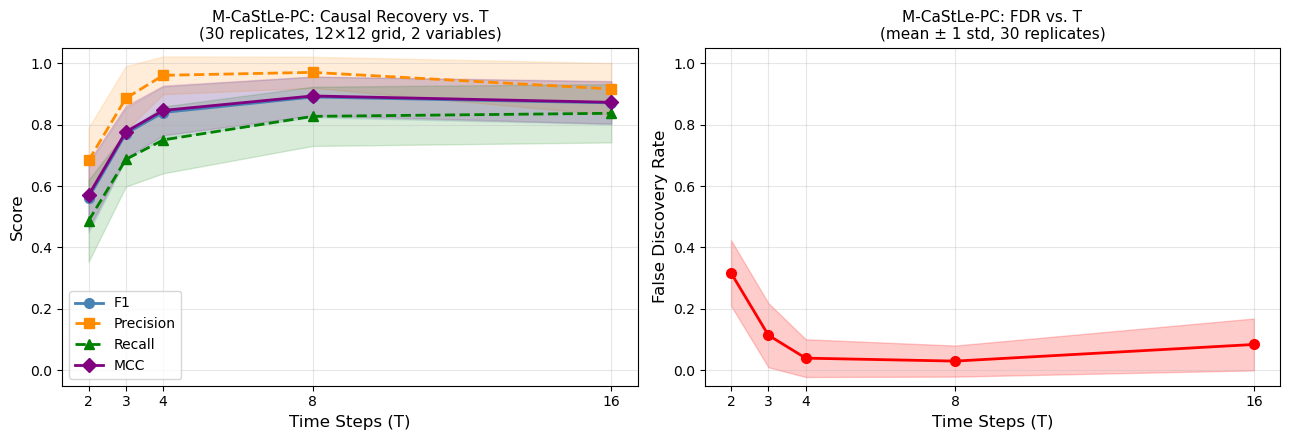

In [6]:
T_arr = np.array(T_VALUES)

def get_mean_std(key):
    means = np.array([agg_results[T][key][0] for T in T_VALUES])
    stds  = np.array([agg_results[T][key][1] for T in T_VALUES])
    return means, stds

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: F1 / Precision / Recall / MCC ---
ax = axes[0]
styles = [
    ("F1",        "steelblue",  "o-"),
    ("Precision", "darkorange", "s--"),
    ("Recall",    "green",      "^--"),
    ("MCC",       "purple",     "D-"),
]
for key, color, fmt in styles:
    m, s = get_mean_std(key)
    ax.plot(T_arr, m, fmt, color=color, label=key, linewidth=2, markersize=7)
    ax.fill_between(T_arr, m - s, m + s, alpha=0.15, color=color)

ax.set_xlabel("Time Steps (T)", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title(f"M-CaStLe-PC: Causal Recovery vs. T\n({N_REPS} replicates, {GRID_SIZE}×{GRID_SIZE} grid, {N_VARS} variables)", fontsize=11)
ax.set_xticks(T_arr)
ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# --- Right: FDR ---
ax = axes[1]
m, s = get_mean_std("FDR")
ax.plot(T_arr, m, "ro-", linewidth=2, markersize=7)
ax.fill_between(T_arr, m - s, m + s, alpha=0.2, color="red")
ax.set_xlabel("Time Steps (T)", fontsize=12)
ax.set_ylabel("False Discovery Rate", fontsize=12)
ax.set_title(f"M-CaStLe-PC: FDR vs. T\n(mean ± 1 std, {N_REPS} replicates)", fontsize=11)
ax.set_xticks(T_arr)
ax.set_ylim(-0.05, 1.05)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Box Plots of F1 and MCC Across Replicates

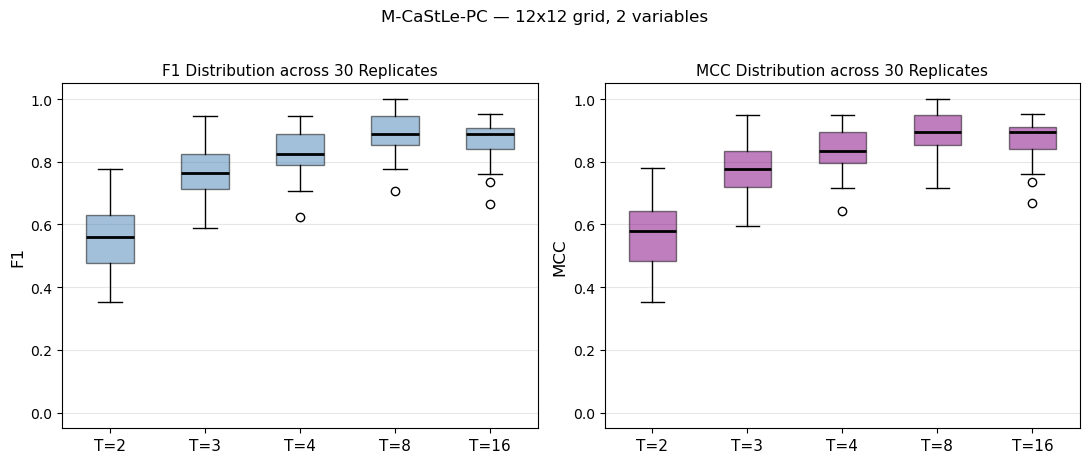

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, key, color in zip(axes, ["F1", "MCC"], ["steelblue", "purple"]):
    data_per_T = [[r[key] for r in results_by_T[T]] for T in T_VALUES]
    bp = ax.boxplot(data_per_T, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))
    for patch in bp["boxes"]:
        patch.set_facecolor(color)
        patch.set_alpha(0.5)
    ax.set_xticklabels([f"T={T}" for T in T_VALUES], fontsize=11)
    ax.set_ylabel(key, fontsize=12)
    ax.set_title(f"{key} Distribution across {N_REPS} Replicates", fontsize=11)
    ax.set_ylim(-0.05, 1.05)
    ax.grid(True, axis="y", alpha=0.3)

plt.suptitle(f"M-CaStLe-PC — {GRID_SIZE}x{GRID_SIZE} grid, {N_VARS} variables", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Edge Count Breakdown (Mean ± Std)

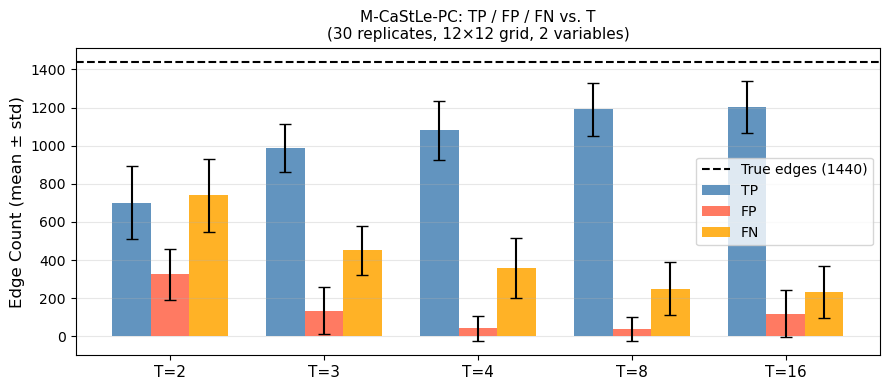

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))

width = 0.25
x = np.arange(len(T_VALUES))

for offset, key, color, label in [
    (-width, "TP", "steelblue", "TP"),
    (0,      "FP", "tomato",    "FP"),
    (width,  "FN", "orange",    "FN"),
]:
    m, s = get_mean_std(key)
    ax.bar(x + offset, m, width, yerr=s, label=label, color=color, capsize=4, alpha=0.85)

ax.axhline(n_true_edges, linestyle="--", color="black", linewidth=1.5,
           label=f"True edges ({n_true_edges})")
ax.set_xticks(x)
ax.set_xticklabels([f"T={T}" for T in T_VALUES], fontsize=11)
ax.set_ylabel("Edge Count (mean ± std)", fontsize=12)
ax.set_title(f"M-CaStLe-PC: TP / FP / FN vs. T\n({N_REPS} replicates, {GRID_SIZE}×{GRID_SIZE} grid, {N_VARS} variables)", fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## Aggregate Stencil Heatmaps

Each cell shows the **fraction of replicates** in which that stencil edge was discovered, for each T.

In [9]:
def stencil_edge_freq(T):
    """Fraction of replicates that discovered each stencil edge (collapsed over lags)."""
    N = true_stencil.shape[0]
    freq = np.zeros((N, N))
    for r in results_by_T[T]:
        for tau in range(r["stencil"].shape[2]):
            freq += (r["stencil"][:, :, tau] == "-->").astype(float)
    return freq / N_REPS

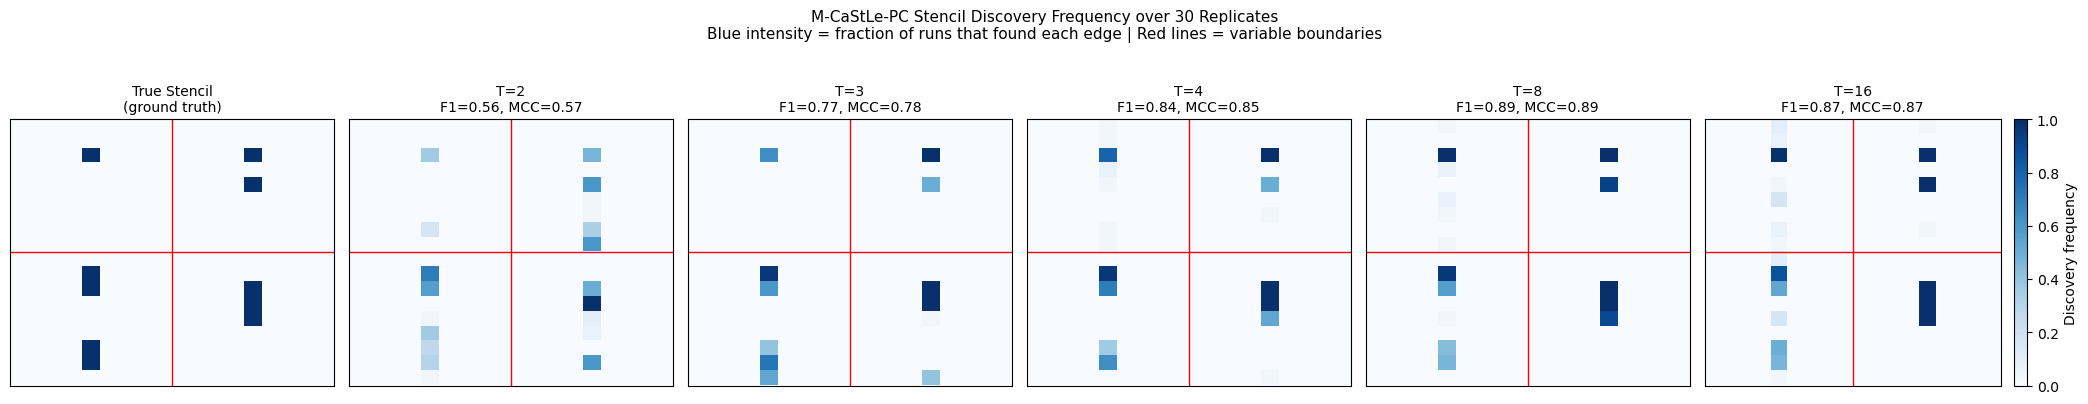

In [10]:
def plot_stencil_ax(ax, mat, title, vmax=1.0):
    N = mat.shape[0]
    im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=vmax, aspect="auto")
    ax.set_title(title, fontsize=10)
    ax.set_xticks([])
    ax.set_yticks([])
    for k in range(1, N_VARS):
        ax.axhline(9 * k - 0.5, color="red", linewidth=1)
        ax.axvline(9 * k - 0.5, color="red", linewidth=1)
    return im

true_bin = np.clip(
    sum((true_stencil[:, :, tau] == "-->").astype(float) for tau in range(true_stencil.shape[2])),
    0, 1
)

n_cols = 1 + len(T_VALUES)
fig, axes = plt.subplots(1, n_cols, figsize=(3.5 * n_cols, 3.8))

plot_stencil_ax(axes[0], true_bin, "True Stencil\n(ground truth)")

for idx, T in enumerate(T_VALUES):
    freq = stencil_edge_freq(T)
    mean_f1  = agg_results[T]["F1"][0]
    mean_mcc = agg_results[T]["MCC"][0]
    im = plot_stencil_ax(
        axes[idx + 1], freq,
        f"T={T}\nF1={mean_f1:.2f}, MCC={mean_mcc:.2f}",
    )

fig.colorbar(im, ax=axes[-1], fraction=0.046, pad=0.04, label="Discovery frequency")
plt.suptitle(
    f"M-CaStLe-PC Stencil Discovery Frequency over {N_REPS} Replicates\n"
    "Blue intensity = fraction of runs that found each edge | Red lines = variable boundaries",
    y=1.03, fontsize=11
)
plt.tight_layout()
plt.show()